In [15]:
import networkx as nx
import matplotlib.pyplot as plt

In [11]:
def find_communities(name, LIMIT=30):
    # load the network
    G = nx.read_gml(f"Networks/{name}.gml")
    
    # find communities based on modularity
    c = nx.community.greedy_modularity_communities(G)

    
    # set the community attribute for each graph
    bb = {}
    for i in range(len(c)):
        for n in c[i]:
            bb[n] = i

    # update original graph
    nx.set_node_attributes(G, bb, 'community')
    
    # save updated graph
    nx.write_gml(G, f"Networks/{name}_c.gml")

In [9]:
# find and save communites for all generated networks
find_communities('t3_p007p_f007p')
find_communities('t3_r007p_f007p')
find_communities('t3_r007p_p007p')
find_communities('t3_r007p_p007p_f007p')

In [ ]:
def find_kplexes(name):
    # load the network
    G = nx.read_gml(f"Networks/{name}.gml")
    
    # find communities based on modularity
    c = nx.community.greedy_modularity_communities(G)

    
    # set the community attribute for each graph
    bb = {}
    for i in range(len(c)):
        for n in c[i]:
            bb[n] = i

    # update original graph
    nx.set_node_attributes(G, bb, 'community')
    
    # save updated graph
    nx.write_gml(G, f"Networks/{name}_kc.gml")

In [30]:
def analyze_community(g_name):
    print(f"Analyzing {g_name}...")
    G = nx.read_gml(f'Networks/{g_name}_c.gml')

    communities = {}
    for n, d in G.nodes(data=True):
        c = d['community']
        if communities.get(c):
            communities[c].append(n)
        else:
            communities[c] = [n]

    # get the sizes
    c_size = [len(communities[c]) for c in communities]
    c_size.sort()
    
    
    print(f"Number of communities: {len(c_size)}")
    print(f"Minimum community size: {min(c_size)}")
    print(f"Average community size: {sum(c_size) / len(c_size)}")
    print(f"Maximum community size: {max(c_size)}")
    plt.xlabel('Community')
    plt.ylabel('Community Size')
    plt.plot([i / len(c_size) for i in range(len(c_size))], c_size)
    plt.savefig(f'Illustrations/{g_name}_cdist.png')
    plt.show()
    

Analyzing t3_r007p_f007p...
Number of communities: 43
Minimum community size: 1
Average community size: 46.48837209302326
Maximum community size: 905


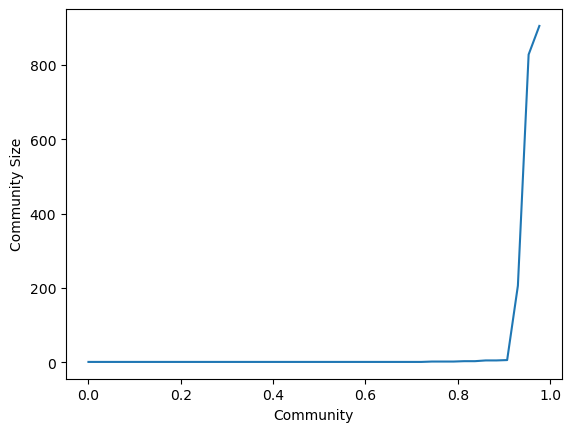

Analyzing t3_r007p_p007p...
Number of communities: 50
Minimum community size: 1
Average community size: 39.98
Maximum community size: 796


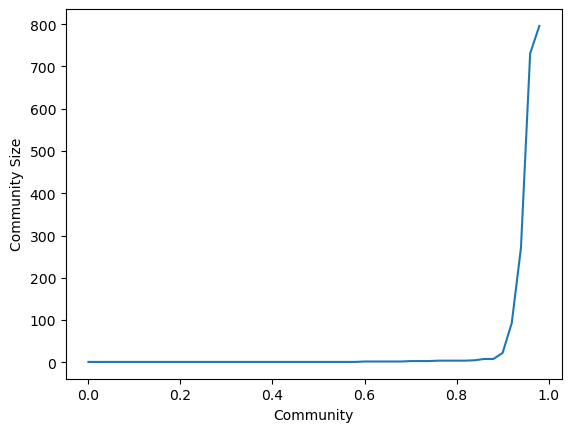

Analyzing t3_r007p_p007p_f007p...
Number of communities: 753
Minimum community size: 1
Average community size: 2.6547144754316068
Maximum community size: 52


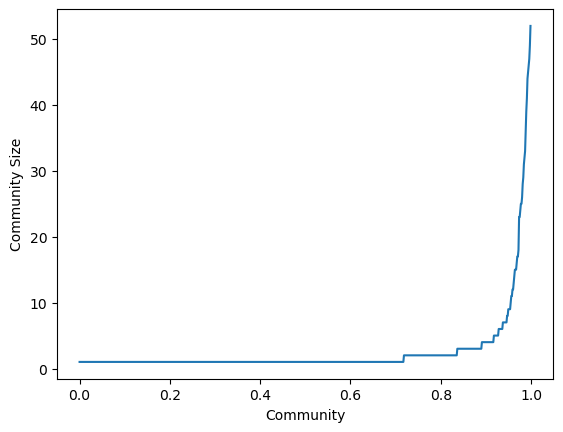

Analyzing t3_p007p_f007p...
Number of communities: 733
Minimum community size: 1
Average community size: 2.727148703956344
Maximum community size: 54


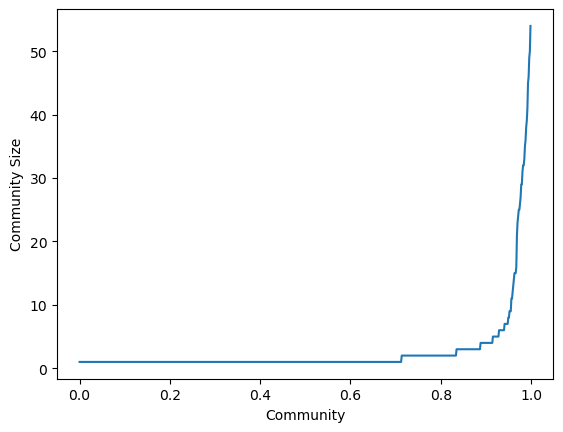

In [31]:
for g_name in ['t3_r007p_f007p', 't3_r007p_p007p', 't3_r007p_p007p_f007p', 't3_p007p_f007p']:
    analyze_community(g_name)